<a href="https://colab.research.google.com/github/ZivBNS/Introduction-to-Cloud-Computing/blob/main/targil4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


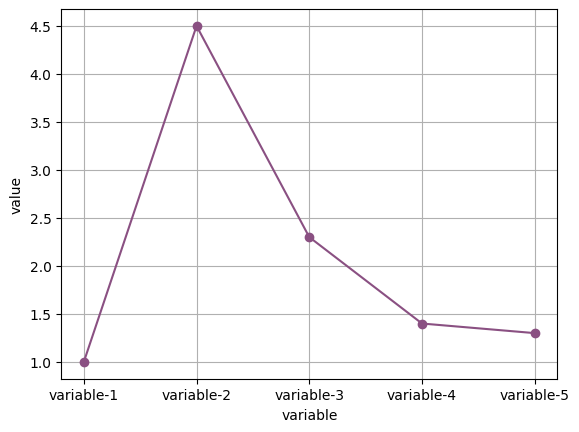

In [1]:
import matplotlib.pyplot as plt
import json


from google.colab import drive
drive.mount('/content/drive')
dictionary = json.load(open('/content/drive/My Drive/3_1.json', 'r'))
xAxis = [key for key, value in dictionary.items()]
yAxis = [value for key, value in dictionary.items()]
plt.grid(True)

## LINE GRAPH ##
plt.plot(xAxis,yAxis, color='#8a5082', marker='o')
plt.xlabel('variable')
plt.ylabel('value')

plt.show()



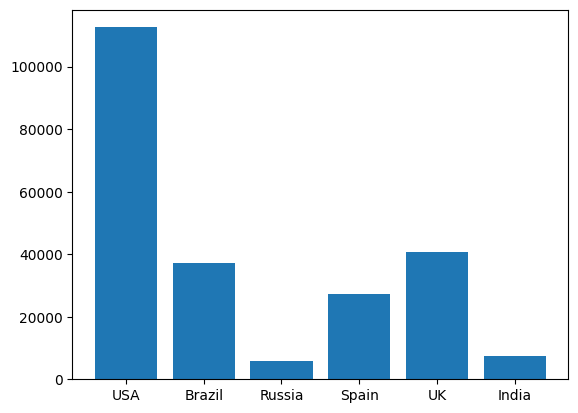

In [2]:
# Importing the matplotlib library
import matplotlib.pyplot as plt

# Categorical data: Country names
countries = ['USA', 'Brazil', 'Russia', 'Spain', 'UK', 'India']

# Integer value interms of death counts
totalDeaths = [112596, 37312, 5971, 27136, 40597, 7449]

# Passing the parameters to the bar function, this is the main function which creates the bar plot
plt.bar(countries, totalDeaths)

# Displaying the bar plot
plt.show()


In [3]:
import pandas as pd

a = [1, 7, 2]

myvar = pd.Series(a)

print(myvar)
print(myvar[0])


0    1
1    7
2    2
dtype: int64
1


In [4]:
url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=053cea08-09bc-40ec-8f7a-156f0677aff3'

import requests
import pandas as pd
pd.set_option("display.max_columns", None)

response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)

data_df = pd.DataFrame(data['result']['records'])


data_df.head() #יציג את 5 השורות הראשונות של הנתונים



,_id,mispar_rechev,tozeret_cd,sug_degem,tozeret_nm,degem_cd,degem_nm,ramat_gimur,ramat_eivzur_betihuty,kvutzat_zihum,shnat_yitzur,degem_manoa,mivchan_acharon_dt,tokef_dt,baalut,misgeret,tzeva_cd,tzeva_rechev,zmig_kidmi,zmig_ahori,sug_delek_nm,horaat_rishum,moed_aliya_lakvish,kinuy_mishari
0,1,1000032,830,P,מרצדס בנץ ארהב,25,166.873,PREMIUM,2.0,15.0,2014,M278,2026-01-23,2027-02-04,פרטי,WDC1668731A340161,10,שחור,295/40R21,295/40R21,בנזין,140154.0,2014-2,GL500 4MATIC
1,2,1000033,74,P,אלפא רומיאו,77,940FXR11,QV VOLANTE,NaN,15.0,2015,940B2000,2025-06-05,2026-06-10,פרטי,ZAR94000007383291,50,אדום,225/40ZR18,225/40ZR18,בנזין,150057.0,2015-6,ALFA GIULIETTA
2,3,1000010,413,M,טויוטה יפן,3000,VZJ90L-GJPNKW,STD,NaN,NaN,2001,5VZ,2026-01-14,2026-08-04,פרטי,JTEAN99J010005167,0,לא ידוע,265\70 R16,265\70 R16,בנזין,NaN,None,PRADO
3,4,1000011,197,P,מרצדס-בנץ אוסט,3,463.202,CABRIO PREMI,NaN,15.0,2012,M273,2026-02-24,2026-12-18,פרטי,WDB4632021X203975,10,שחור,265/60R18,265/60R18,בנזין,122102.0,2012-12,G500
4,5,1000068,683,P,סוזוקי-יפן,292,JTD54V,JLX,NaN,15.0,2008,J20A,2025-11-12,2026-11-29,פרטי,JSAJTD54V90300319,80,שנהב לבן,225/70R16,225/70R16,בנזין,NaN,2008-11,GRAND VITARA


In [22]:
import requests
import pandas as pd
from ipywidgets import widgets, VBox, Output
from IPython.display import display

# API URL for Israeli vehicle data
url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=053cea08-09bc-40ec-8f7a-156f0677aff3'

# 1. Fetch and Prepare Data
try:
    response = requests.get(url)
    data = response.json()
    data_df = pd.DataFrame(data['result']['records'])
    # Clean up empty strings or NaNs to avoid errors in dropdowns
    data_df['kinuy_mishari'] = data_df['kinuy_mishari'].fillna('N/A')
    data_df['ramat_gimur'] = data_df['ramat_gimur'].fillna('N/A')
except Exception as e:
    print(f"Error fetching data: {e}")

# 2. Initialize Widgets
output_area = Output()

tozeret_nm_dropdown = widgets.Dropdown(
    options=[''] + sorted(data_df['tozeret_nm'].unique().tolist()),
    description='Tozeret:',
    style={'description_width': 'initial'}
)

kinuy_mishari_dropdown = widgets.Dropdown(
    options=[''],
    description='Kinuy Mishari:',
    style={'description_width': 'initial'}
)

# 3. Define Callback Functions
def update_kinuy_mishari_options(change):
    """Updates the second dropdown based on the selection of the first."""
    if change['new']:
        filtered_values = data_df[data_df['tozeret_nm'] == change['new']]['kinuy_mishari'].unique()
        kinuy_mishari_dropdown.options = [''] + sorted(filtered_values.tolist())
    else:
        kinuy_mishari_dropdown.options = ['']
    # Clear output when manufacturer changes
    update_output()

def update_output(change=None):
    """Calculates and displays the results."""
    output_area.clear_output()
    selected_tozeret = tozeret_nm_dropdown.value
    selected_kinuy = kinuy_mishari_dropdown.value

    with output_area:
        if selected_tozeret and selected_kinuy:
            filtered_df = data_df[
                (data_df['tozeret_nm'] == selected_tozeret) &
                (data_df['kinuy_mishari'] == selected_kinuy)
            ]
            total_records = len(filtered_df)
            unique_ramat_gimur = filtered_df['ramat_gimur'].unique()

            print(f"Total Records: {total_records}")
            print(f"Unique Ramat Gimur: {', '.join(map(str, unique_ramat_gimur))}")
        else:
            print("Please select valid options for both dropdowns.")

# 4. Bind Observers
tozeret_nm_dropdown.observe(update_kinuy_mishari_options, names='value')
kinuy_mishari_dropdown.observe(update_output, names='value')

# 5. Display UI
display(VBox([tozeret_nm_dropdown, kinuy_mishari_dropdown, output_area]))

Fetching data from the API... Please wait.
Data loaded successfully! Generating dashboard...


    'data': [{'branchvalues': 'total',
              'domain': {'x…

In [6]:
import pandas as pd
import plotly.express as px

# Create a sample dataframe
data = {
    "Country": ["Germany", "France", "Italy", "Spain", "United Kingdom"],
    "GDP": [3.8, 2.7, 1.9, 1.4, 2.1],
    "Population": [83, 67, 60, 47, 66],
    "Vehicles Fleet": [50, 35, 40, 30, 45]
}

df = pd.DataFrame(data)

# Create a scatter matrix
fig = px.scatter_matrix(df,
                        dimensions=["GDP", "Population", "Vehicles Fleet"],
                        color="Country",
                        title="Scatter Matrix: Country GDP, Population, and Vehicles Fleet in Europe")

# Display the scatter matrix
fig.show()


In [7]:
from plotly.offline import iplot
import plotly.graph_objs as go

data = [
    go.Contour(
        z=[[10, 10.625, 12.5, 15.625, 20],
           [5.625, 6.25, 8.125, 11.25, 15.625],
           [2.5, 3.125, 5., 8.125, 12.5],
           [0.625, 1.25, 3.125, 6.25, 10.625],
           [0, 0.625, 2.5, 5.625, 10]]
    )
]
iplot(data)



In [8]:
import plotly.graph_objects as go
import datetime
import numpy as np

# Set seed for reproducibility
np.random.seed(1)

programmers = ['Alex', 'Nicole', 'Sara', 'Etienne', 'Chelsea', 'Jody', 'Marianne']
base = datetime.datetime.today()

# Create a list of dates for the last 180 days
dates = [base - datetime.timedelta(days=x) for x in range(180)]

# Generate random Poisson data to simulate daily commits
z = np.random.poisson(lam=2, size=(len(programmers), len(dates)))

# Create the Heatmap
fig = go.Figure(data=go.Heatmap(
    z=z,
    x=dates,
    y=programmers,
    colorscale='Viridis'  # Fixed the curly quote here
))

# Update Layout
fig.update_layout(
    title=dict(text='GitHub Commits Per Day'),
    xaxis=dict(
        title='Date',
        nticks=36,
        tickformat='%b %d' # Makes dates easier to read (e.g., "Oct 12")
    ),
    yaxis=dict(title='Programmer'),
    template='plotly_white'
)

fig.show()

In [9]:
# Plotly version
import plotly.express as px
df = pd.DataFrame({'x': range(10), 'y': [i**2 for i in range(10)]})
fig = px.scatter(df, x='x', y='y', title='Plotly Scatter')
fig.show()

# Bokeh version
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
output_notebook()

p = figure(title='Bokeh Scatter')
p.scatter(df['x'], df['y'])
show(p)


In [13]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from plotly.offline import iplot
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  #seaborn for heatmap


# Create a simple DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'City': ['New York', 'Los Angeles', 'Chicago']
}
df = pd.DataFrame(data)
# Tab 1: Data Overview
tab1_content = widgets.Output()
with tab1_content:
    print("Data Overview:")
    display(df.describe())  # Summary statistics

# Tab 2: Raw Data
tab2_content = widgets.Output()
with tab2_content:
    print("Raw Data:")
    display(df)  # Full DataFrame
# Tab 3: Charts
tab3_content = widgets.Output()
with tab3_content:
    print("Charts:")
    plt.clf()  # Clear the current figure
    plt.figure(figsize=(10, 8))  # Increased figure size to accommodate labels
    side_length = 10
    data = 5 + np.random.randn(side_length, side_length)
    data += np.arange(side_length)
    data += np.reshape(np.arange(side_length), (side_length, 1))

    # Create heatmap with labels
    heatmap = sns.heatmap(data,
                         cmap='viridis',
                         annot=True,
                         fmt='.1f',
                         cbar_kws={'label': 'Value Intensity'})
    plt.title('Enhanced Heatmap with Labels')
    plt.xlabel('X Axis Position')
    plt.ylabel('Y Axis Position')
    plt.show()  # Add this to display the plot
    plt.close()  # Close the figure t free memory
# Create Tabs
tabs = widgets.Tab(children=[tab1_content, tab2_content,tab3_content])
tabs.set_title(0, 'Tab 1: Data Overview')
tabs.set_title(1, 'Tab 2: Raw Data')
tabs.set_title(2, 'Tab 3: Charts')



# Display Tabs
display(tabs)


In [26]:
import requests
import pandas as pd
import plotly.express as px
from IPython.display import display
from google.colab import widgets

# --- 1. Fetch and Prepare Data ---
url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=053cea08-09bc-40ec-8f7a-156f0677aff3&limit=1000'
try:
    response = requests.get(url)
    data = response.json()
    data_df = pd.DataFrame(data['result']['records'])

    # Clean up empty strings or NaNs
    data_df['kinuy_mishari'] = data_df['kinuy_mishari'].fillna('N/A')
    data_df['ramat_gimur'] = data_df['ramat_gimur'].fillna('N/A')
    data_df['tozeret_nm'] = data_df['tozeret_nm'].fillna('N/A')

    # Convert production year to numeric for the graph, drop missing years
    data_df['shnat_yitzur'] = pd.to_numeric(data_df['shnat_yitzur'], errors='coerce')
    data_df = data_df.dropna(subset=['shnat_yitzur'])
    data_df['shnat_yitzur'] = data_df['shnat_yitzur'].astype(int)


except Exception as e:
    print(f"Error fetching data: {e}")

# --- 2. Build Colab-Native Tabs ---
# This creates the tabs physically in the Colab output cell
tb = widgets.TabBar(['Statistics', 'Data Table', 'Yearly Graph'])

# --- Tab 1: Statistics ---
with tb.output_to('Statistics'):
    stats_df = data_df[data_df['tozeret_nm'] != 'N/A']
    fig_stats = px.sunburst(
        stats_df,
        path=['tozeret_nm', 'kinuy_mishari'],
        title="Overall Statistics: Manufacturers and Models",
        height=600
    )
    fig_stats.show()

# --- Tab 2: Data Table ---
with tb.output_to('Data Table'):
    display(data_df)

# --- Tab 3: Yearly Graph ---
with tb.output_to('Yearly Graph'):
    yearly_counts = data_df.groupby('shnat_yitzur').size().reset_index(name='Total Cars')
    yearly_counts = yearly_counts.sort_values('shnat_yitzur')

    fig_year = px.bar(
        yearly_counts,
        x='shnat_yitzur',
        y='Total Cars',
        title="Number of Vehicles Produced Per Year",
        labels={'shnat_yitzur': 'Production Year'},
        color='Total Cars',
        color_continuous_scale='Viridis',
        height=500
    )
    fig_year.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>